# Run the complete election pipeline
Evaluate eight candidates across five outer elections, select by equal-weight mean accuracy, then retune, refit and evaluate 2024. Configure PostgreSQL and the tracking server first using docs/postgresql.md and docs/mlflow.md. The pipeline automatically reads .env.election. Source .mlflow/config.env before starting Jupyter for tracking settings. Rerun the setup cell below after updating the database code, including in an existing kernel.

Prepared CSVs, predictor guide, final predictions and confusion matrices remain in outputs. Compact experiment histories are retained in MLflow.


In [1]:
import os
import importlib

# Use the local tracking server unless a server is already configured.
os.environ.setdefault("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")

from election import paths
from election.sql import apply_sql_queries

# Refresh database setup when this cell is rerun in an existing kernel.
importlib.reload(apply_sql_queries)
from election.pipeline.run_pipeline import run_pipeline

project_root = paths.project_root()

output_directory = project_root / "outputs"
print(f"Saving pipeline outputs to: {output_directory}")


Saving pipeline outputs to: /workspaces/Election-Prediction-12.08/notebooks/outputs


In [2]:
# This runs preparation, all historical evaluations, comparison, and final 2024 evaluation.
# To reuse data, pass prepared_data=output_directory / "latest_prepared.json".
# To reuse recorded historical evaluations as well, add reuse_evaluations=True.
selection = run_pipeline(output_dir=output_directory)
import pandas as pd
from IPython.display import display
comparison = selection["comparison"]
final_evaluation = selection["final_evaluation"]
display(pd.DataFrame(comparison["ranked_results"]))
print("Selected model:", comparison["winner_model_id"])
print("Historical source runs:", comparison["source_run_ids"])
print("Final MLflow run:", final_evaluation["run_id"])
print("Prepared data:", selection["prepared_data"])


/workspaces/Election-Prediction-12.08/.venv/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Outer election 2005: tuning and fitting xgboost
Outer election 2010: tuning and fitting xgboost
Outer election 2015: tuning and fitting xgboost
Outer election 2017: tuning and fitting xgboost
Outer election 2019: tuning and fitting xgboost
🏃 View run xgboost: historical-five-election-v1 at: http://127.0.0.1:5000/#/experiments/67/runs/710f1106db074b42bd8ee93bfe38f596
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
Outer election 2005: tuning and fitting random_forest
Outer election 2010: tuning and fitting random_forest
Outer election 2015: tuning and fitting random_forest
Outer election 2017: tuning and fitting random_forest
  RandomForest: 18/18 configurations scored
Outer election 2019: tuning and fitting random_forest
  RandomForest: 17/18 configurations scored
🏃 View run random_forest: historical-five-election-v1 at: http://127.0.0.1:5000/#/experiments/67/runs/b3ee13471da9477ba92268ffe2d4975f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
Outer election 2

,model_id,mean_outer_accuracy,run_id,completed_at
0,conditional_xgboost,0.888176,422d3a36ee624753bfbd38cad6e59cbe,1791136935693
1,xgboost_expanded,0.877114,fc0376b7c5df4aeabf5e96644945367e,1791136827504
2,xgboost,0.875210,710f1106db074b42bd8ee93bfe38f596,1791135610466
3,random_forest,0.871719,b3ee13471da9477ba92268ffe2d4975f,1791135765184
4,nn03,0.861590,15be0adb6d224bc98f13542daf964263,1791136802082
5,nn01,0.861286,22d43f335e8343dea7005981a041f9e1,1791135998356
6,logistic_regression,0.860016,935bc9437d304eb4bec7419a54fa43ef,1791135769404
7,nn02,0.857468,9ff09212d08441f1b4ec2f7f1cd14740,1791136730056


Selected model: conditional_xgboost
Historical source runs: {'conditional_xgboost': '422d3a36ee624753bfbd38cad6e59cbe', 'xgboost_expanded': 'fc0376b7c5df4aeabf5e96644945367e', 'xgboost': '710f1106db074b42bd8ee93bfe38f596', 'random_forest': 'b3ee13471da9477ba92268ffe2d4975f', 'nn03': '15be0adb6d224bc98f13542daf964263', 'nn01': '22d43f335e8343dea7005981a041f9e1', 'logistic_regression': '935bc9437d304eb4bec7419a54fa43ef', 'nn02': '9ff09212d08441f1b4ec2f7f1cd14740'}
Final MLflow run: 8c30d51cdf4646efb4ecb004a02d38df
Prepared data: {'data_id': '6812e57c08cc604171ab26f161bac2ab0653849f6b945fce4deaa2beb930f424', 'test_data_id': 'f826113d72f5b57cf7c93e9f0b0a5d91087d78765155c6e439f40403b1a9b790', 'train_path': '/workspaces/Election-Prediction-12.08/notebooks/outputs/datasets/bbd4beeb209abbbef8c82a72b65c5df80399c80af059990f6ad2943119dfdd27/train.csv', 'test_path': '/workspaces/Election-Prediction-12.08/notebooks/outputs/datasets/bbd4beeb209abbbef8c82a72b65c5df80399c80af059990f6ad2943119dfdd27/te

## Final 2024 results
The pipeline has already evaluated and logged the final model. These cells display returned results and the saved confusion matrix.


hyperparameters        {'challenger.max_depth': 2, 'challenger.n_esti...
mean_inner_accuracy                                              0.88314
inner_accuracies       {1997: 0.7769110764430577, 2001: 0.95943837753...
accuracy                                                        0.737342
training_years         (1987, 1992, 1997, 2001, 2005, 2010, 2015, 201...
refit_durations                                                       {}
evaluation_rows                                                      632
excluded_rows                                                          0
Name: 2024, dtype: object

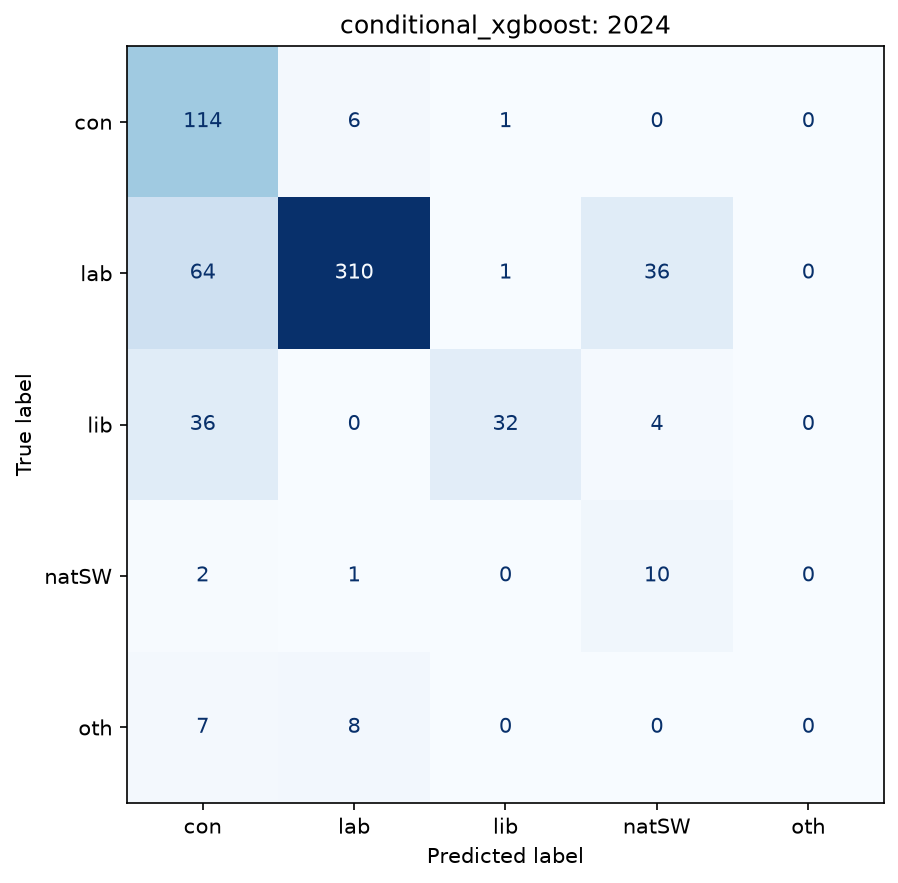

In [3]:
display(pd.Series(final_evaluation["outer_results"][2024], name="2024"))
from IPython.display import Image, display
display(Image(filename=str(output_directory / "test_confusion_matrix.png")))
